<a href="https://colab.research.google.com/github/GabiGalettiRusca/GabiGalettiRusca/blob/main/ISS_Exercicio_Gabriela_Galetti_Rusca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo do Índice de Saúde do Solo (ISS) para uma área de cacau no Sul da Bahia

**Disciplina:** LSO5924 — Saúde do Solo  
**Exercício:** cálculo de índice de saúde do solo a partir da planilha da Aula 9  
**Cenário adaptado:** o sistema originalmente chamado de “Agricultura” é interpretado como **monocultura de cacau no Sul da Bahia**  
**Autoria**: Gabriela Galetti Rusca
**Escala final:** 0–100  

Este notebook foi preparado para ser aberto e executado no **Google Colab**. Ele contém os dados do exercício incorporados diretamente no próprio notebook, de modo que a análise pode ser reproduzida sem upload de arquivo. Se desejar, também é possível substituir a base embutida por uma planilha própria, mantendo a mesma estrutura de colunas.

A lógica geral segue três etapas usadas em índices de qualidade/saúde do solo: **seleção de indicadores**, **transformação dos valores em escores padronizados** e **integração dos escores em um índice final**. Essa abordagem é coerente com o **Soil Management Assessment Framework (SMAF)**, que permite adaptar curvas de scoring a condições locais, funções do solo e julgamento especialista quando necessário [1].

## 1. O que será feito neste notebook

A planilha original possui três usos da terra: **vegetação nativa**, **agricultura** e **pastagem**. Neste exercício, a categoria **Agricultura** será renomeada para **Monocultura de cacau**, representando uma área de cacau no Sul da Bahia. A vegetação nativa será usada como referência ecológica para calcular o **Soil Health Gap**, ou seja, a distância de cada sistema em relação à condição menos perturbada.

| Etapa | O que será feito | Por que isso é necessário |
|---|---|---|
| 1 | Ler a base de dados | Organizar os indicadores da planilha |
| 2 | Renomear “Agricultura” para “Monocultura de cacau” | Adaptar o exercício ao contexto do cacau no Sul da Bahia |
| 3 | Calcular escores de 0 a 1 | Colocar indicadores com unidades diferentes na mesma escala |
| 4 | Calcular subíndices químico, físico e biológico | Interpretar dimensões diferentes da saúde do solo |
| 5 | Calcular ISS final em escala 0–100 | Produzir uma nota integrada de saúde do solo |
| 6 | Calcular Soil Health Gap | Comparar cacau e pastagem com a vegetação nativa |
| 7 | Gerar tabelas, gráficos e planilha final | Facilitar a entrega e a reprodução do exercício |

## 2. Instalação e importação dos pacotes

No Colab, os pacotes principais geralmente já estão instalados. Mesmo assim, a célula abaixo instala ou atualiza o pacote `openpyxl`, usado para exportar a planilha Excel final. Depois, importamos as bibliotecas necessárias.

In [1]:
# Instala o pacote usado para salvar arquivos Excel.
# O comando é silencioso (-q) para não poluir a saída do notebook.
%pip install -q openpyxl

In [2]:
# Bibliotecas para organizar dados, fazer cálculos e gerar gráficos.
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Bibliotecas para formatar e salvar a planilha Excel final.
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter

# Ajuste visual dos gráficos.
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

## 3. Base de dados do exercício

A base abaixo é a planilha da Aula 9 já limpa e incorporada ao notebook. Cada linha representa uma repetição/amostra e cada coluna representa um indicador. Os indicadores usados são:

| Componente | Indicadores | Interpretação geral |
|---|---|---|
| Químico | pH, fósforo, potássio | Disponibilidade de nutrientes e adequação química |
| Físico | Densidade, macroagregação | Compactação, estrutura e estabilidade física |
| Biológico | BG, COS, CBM | Atividade enzimática, carbono orgânico e biomassa microbiana |

No exercício, **BG** representa atividade de β-glicosidase, **COS** representa carbono orgânico do solo e **CBM** representa carbono da biomassa microbiana.

In [3]:
# -------------------------------------------------------------------------
# DADOS INCORPORADOS AO NOTEBOOK
# -------------------------------------------------------------------------
# Para tornar o notebook replicável, os dados foram salvos aqui como texto CSV.
# Isso evita depender de upload externo no Google Colab.

csv_dados = """Uso da terra,Repetição,pH,Fósforo,Potássio,Densidade,Macroagregação,BG,COS,CBM
Vegetação nativa,1,4.4858,4.2,35.972,1.3194883688242323,93.34,45.07873132121817,1.46,228.61681663046863
Vegetação nativa,2,4.2092,6.4,46.92,1.2032937428256847,92.16,42.430496682804375,1.6299999999999997,534.152676591701
Vegetação nativa,3,4.2092,5.6,36.754,1.2725185653711903,93.6,62.54789701860868,1.585,543.0016890213612
Vegetação nativa,4,4.3014,5.6,42.61900000000001,1.206339166490969,89.28,51.8774944783108,1.53,381.9495601173023
Vegetação nativa,5,4.3936,6.6,42.228,1.229531239018905,89.3,53.5064996420902,1.6800000000000002,331.77848775292864
Vegetação nativa,6,4.4858,5.8,45.355999999999995,1.2422985920772134,91.06,43.42753581985153,1.8,421.741374137414
Vegetação nativa,7,4.3936,6.2,36.754,1.2403073535268352,90.54,51.00268258520642,1.545,464.1814271749757
Vegetação nativa,8,4.3014,5.4,37.536,1.251083468034765,92.3,54.600733988966184,1.43,259.4059514059515
Vegetação nativa,9,4.4858,4.2,34.017,1.1125166912643194,86.77999999999999,42.71827292533174,1.3650000000000002,410.25819321744086
Pastagem,1,4.3936,3.0,28.151999999999997,1.6595216342211916,92.0888888888889,41.62371854134566,1.0550000000000002,482.1873911529084
Pastagem,2,4.2092,3.0,19.941,1.6236793403143817,92.19999999999999,40.21375363290854,1.03,331.1605415860733
Pastagem,3,4.3014,2.8,24.241999999999997,1.5539859910511395,90.74,40.004715972152155,0.9650000000000001,407.157894736842
Pastagem,4,4.3014,2.8,30.889,1.6465200178040154,95.02,37.31781654011903,0.9949999999999999,363.64200140944337
Pastagem,5,4.3014,3.4,25.415,1.6885702907208284,91.36000000000001,35.38432647644328,0.8030000000000002,341.13475177304974
Pastagem,6,4.3936,3.0,25.024,1.6888045540796965,94.46,45.42228458847654,0.8525,393.6586574188752
Pastagem,7,4.3014,3.8,26.588,1.692201372783283,91.9,47.41128973476414,0.9595,149.9754299754299
Pastagem,8,4.3936,2.6,13.684999999999999,1.5565628879986881,93.12000000000002,31.679807315546032,0.9200000000000002,142.49201694362986
Pastagem,9,4.3014,2.8,21.114,1.5722585330428467,94.22857142857143,40.88908444157,1.01,102.30030643513774
Agricultura,1,5.5,5.4,17.204,1.2619767142221285,60.399999999999984,45.96329545454545,1.03,315.15076923076924
Agricultura,2,5.4078,8.6,21.114,1.1596039793380521,72.80000000000001,54.05913967258795,1.17,393.1562901744719
Agricultura,3,5.8688,8.4,14.075999999999999,1.3598987982289688,89.74,54.95520657205572,1.1150000000000002,376.34730538922156
Agricultura,4,5.5,7.6,21.505000000000003,1.6872818422470541,73.94,33.231464260929904,1.295,417.7832980972515
Agricultura,5,5.592199999999999,4.8,28.933999999999997,1.1074800290486564,84.64,34.96731606891321,1.03,349.99209486166023
Agricultura,6,5.4078,4.8,37.144999999999996,1.251801196727317,72.1,28.084532091900513,1.065,330.22082897944966
Agricultura,7,5.4078,8.6,29.716,1.2975943338624985,69.78000000000002,55.16468612917863,1.1150000000000002,409.2440739775983
Agricultura,8,5.5,5.4,26.588,1.1041228237995027,65.97142857142858,51.71451984635084,0.8845000000000001,567.3389355742298
Agricultura,9,5.7766,12.2,19.55,1.107709967476564,70.61999999999999,66.5218010129625,1.06,574.0470608665452"""

# O pandas lê o texto CSV como se fosse um arquivo.
df = pd.read_csv(io.StringIO(csv_dados))

# Para este exercício, a categoria "Agricultura" será interpretada como cacau.
df["Uso da terra"] = df["Uso da terra"].replace({"Agricultura": "Monocultura de cacau"})

# Alias explícito para facilitar a leitura e a validação do notebook.
# Neste notebook, `dados` é a base principal do exercício já adaptada para cacau.
dados = df.copy()

# Mostra as primeiras linhas para conferir se a base foi carregada corretamente.
dados.head()

,Uso da terra,Repetição,pH,Fósforo,Potássio,Densidade,Macroagregação,BG,COS,CBM
0,Vegetação nativa,1,4.4858,4.2,35.972,1.319488,93.34,45.078731,1.460,228.616817
1,Vegetação nativa,2,4.2092,6.4,46.920,1.203294,92.16,42.430497,1.630,534.152677
2,Vegetação nativa,3,4.2092,5.6,36.754,1.272519,93.60,62.547897,1.585,543.001689
3,Vegetação nativa,4,4.3014,5.6,42.619,1.206339,89.28,51.877494,1.530,381.949560
4,Vegetação nativa,5,4.3936,6.6,42.228,1.229531,89.30,53.506500,1.680,331.778488


## 4. Decisões metodológicas de scoring

Como os indicadores têm unidades diferentes, primeiro é necessário transformar cada indicador em um **escore entre 0 e 1**. Um escore próximo de 1 indica melhor condição relativa; um escore próximo de 0 indica pior condição relativa, de acordo com a regra adotada para cada indicador.

A maior adaptação para o contexto do cacau ocorreu em **pH**. O pH foi tratado como curva do tipo **optimum**, porque tanto valores muito baixos quanto valores muito altos podem representar limitação e comprometer a funcionalidade do solo em sistemas cacaueiros. Valores baixos foram penalizados por risco de acidez, toxicidade de Al/Mn e menor disponibilidade de bases, enquanto valores elevados foram penalizados por possível redução da disponibilidade de micronutrientes como Zn, Fe e Mn, relevantes para a nutrição da planta e a composição mineral das amêndoas.

O **fósforo disponível**, por outro lado, foi mantido como **“maior é melhor” no exercício**, em coerência com Cherubin et al. (2016), onde P entra como curva *more is better* com limites 2, 8 e 16 mg dm⁻³ e sem penalização por excesso. Como os valores observados na base são baixos a moderados, a discussão sobre excesso de P deve ficar apenas como ressalva para o projeto de doutorado, dependente do método analítico e da textura/argila.

| Indicador | Tipo de curva | Regra adotada | Justificativa |
|---|---|---|---|
| pH | Optimum | Ótimo entre 5,0 e 6,5 | Evita tratar pH excessivamente baixo ou alto como bom |
| Fósforo | Maior é melhor no exercício | Curva Cherubin et al. (2016): 2 → 0; 8 → 0,5; 16 → 1 | Os valores observados permanecem na parte crescente da curva; não há penalização por excesso |
| Potássio | Maior é melhor | Normalização min–máx crescente | Maior disponibilidade relativa foi considerada favorável no exercício |
| Densidade | Menor é melhor | Normalização min–máx decrescente | Menor densidade indica menor compactação relativa |
| Macroagregação | Maior é melhor | Normalização min–máx crescente | Maior agregação indica melhor estrutura |
| BG | Maior é melhor | Normalização min–máx crescente | Maior atividade enzimática indica maior atividade biológica |
| COS | Maior é melhor | Normalização min–máx crescente | Maior carbono orgânico indica maior reserva de matéria orgânica |
| CBM | Maior é melhor | Normalização min–máx crescente | Maior biomassa microbiana indica maior atividade biológica |

 P disponível como curva **more is better**, com limites 2, 8 e 16 mg dm⁻³ e sem penalização por excesso [2]. Para o projeto de doutorado em cacau, a lógica pode ser ampliada para uma curva de faixa ótima apenas quando o método analítico estiver definido. Se for P-resina, a salvaguarda superior pode ser discutida em torno de classes altas/muito altas; se for Mehlich-1, a interpretação deve considerar teor de argila/textura, como reforçado por documentos técnicos da Embrapa [3].

In [4]:
# -------------------------------------------------------------------------
# LISTAS DE INDICADORES E COMPONENTES
# -------------------------------------------------------------------------

# Indicadores disponíveis na planilha.
indicadores = ["pH", "Fósforo", "Potássio", "Densidade", "Macroagregação", "BG", "COS", "CBM"]

# Organização dos indicadores por componente.
# Essa divisão ajuda a interpretar o ISS de forma mais clara.
componentes = {
    "Químico": ["pH", "Fósforo", "Potássio"],
    "Físico": ["Densidade", "Macroagregação"],
    "Biológico": ["BG", "COS", "CBM"],
}

# Unidades usadas apenas para documentar a planilha final.
unidades = {
    "pH": "pH CaCl2, assumido no exercício",
    "Fósforo": "mg dm-3, P disponível da base da aula",
    "Potássio": "mg kg-1",
    "Densidade": "g dm-3",
    "Macroagregação": "%",
    "BG": "µg g-1 h-1",
    "COS": "%",
    "CBM": "mg kg-1",
}

## 5. Funções de scoring

As funções abaixo são a parte central do cálculo. Elas transformam os valores originais em escores de 0 a 1. Funções comentadas para facilitar a leitura e replicação.

In [5]:
# -------------------------------------------------------------------------
# FUNÇÃO 1 — quando "maior é melhor"
# -------------------------------------------------------------------------
def score_maior_melhor(x):
    """
    Transforma um indicador em escore quando valores maiores são considerados melhores.

    Exemplo: carbono orgânico do solo. Em geral, dentro deste exercício,
    valores maiores de COS indicam melhor condição do solo.

    Fórmula: (valor - mínimo) / (máximo - mínimo)
    Resultado: o menor valor observado recebe 0 e o maior valor observado recebe 1.
    """
    x = x.astype(float)
    xmin, xmax = x.min(), x.max()

    # Se todos os valores forem iguais, não há diferença entre amostras.
    # Nesse caso, todos recebem escore 1 para evitar divisão por zero.
    if np.isclose(xmax, xmin):
        return pd.Series(np.ones(len(x)), index=x.index)

    return ((x - xmin) / (xmax - xmin)).clip(0, 1)


# -------------------------------------------------------------------------
# FUNÇÃO 2 — quando "menor é melhor"
# -------------------------------------------------------------------------
def score_menor_melhor(x):
    """
    Transforma um indicador em escore quando valores menores são considerados melhores.

    Exemplo: densidade do solo. Em geral, densidade menor indica menor compactação.

    Fórmula: (máximo - valor) / (máximo - mínimo)
    Resultado: o menor valor observado recebe 1 e o maior valor observado recebe 0.
    """
    x = x.astype(float)
    xmin, xmax = x.min(), x.max()

    if np.isclose(xmax, xmin):
        return pd.Series(np.ones(len(x)), index=x.index)

    return ((xmax - x) / (xmax - xmin)).clip(0, 1)


# -------------------------------------------------------------------------
# FUNÇÃO 3 — pH como curva optimum para cacau
# -------------------------------------------------------------------------
def score_ph_cacau(x):
    """
    Calcula o escore de pH para o contexto de cacau.

    A ideia é que existe uma faixa intermediária mais adequada:
    - pH <= 4,0: escore 0
    - 4,0 < pH < 5,0: escore sobe gradualmente de 0 até 1
    - 5,0 <= pH <= 6,5: escore 1, faixa ótima operacional
    - 6,5 < pH < 7,5: escore cai gradualmente de 1 até 0
    - pH >= 7,5: escore 0

    Essa regra evita considerar que pH sempre melhora quando aumenta.
    """
    x = x.astype(float)
    s = pd.Series(np.zeros(len(x)), index=x.index, dtype=float)

    # Faixa ótima: recebe nota máxima.
    s[(x >= 5.0) & (x <= 6.5)] = 1.0

    # Faixa ácida de transição: melhora progressivamente até o ótimo.
    mask = (x > 4.0) & (x < 5.0)
    s[mask] = (x[mask] - 4.0) / (5.0 - 4.0)

    # Faixa acima do ótimo: piora progressivamente.
    mask = (x > 6.5) & (x < 7.5)
    s[mask] = (7.5 - x[mask]) / (7.5 - 6.5)

    return s.clip(0, 1)


# -------------------------------------------------------------------------
# FUNÇÃO 4 — fósforo no exercício: maior é melhor dentro da faixa observada
# -------------------------------------------------------------------------
def score_p_exercicio(x):
    """
    Fósforo disponível no exercício: regra "maior é melhor" baseada em Cherubin et al. (2016).

    A curva didática usa três pontos: 2 mg dm-3 recebe 0; 8 mg dm-3 recebe 0,5;
    16 mg dm-3 ou mais recebe 1. Valores acima de 16 não são penalizados no exercício.
    Para o projeto em cacau, qualquer penalização por excesso deve depender do método
    analítico do P e da textura/argila do solo.
    """
    x = x.astype(float)
    s = pd.Series(np.zeros(len(x)), index=x.index, dtype=float)

    mask = (x > 2.0) & (x < 8.0)
    s[mask] = 0.5 * (x[mask] - 2.0) / (8.0 - 2.0)

    mask = (x >= 8.0) & (x < 16.0)
    s[mask] = 0.5 + 0.5 * (x[mask] - 8.0) / (16.0 - 8.0)

    s[x >= 16.0] = 1.0
    return s.clip(0, 1)

## 6. Cálculo dos escores, subíndices e ISS

Nesta etapa, aplicamos as funções de scoring a cada indicador. Depois, calculamos três subíndices: **ISS químico**, **ISS físico** e **ISS biológico**. Por fim, calculamos o **ISS ponderado por componentes**, em que cada componente tem o mesmo peso.

\[
ISS = \frac{ISS_{químico} + ISS_{físico} + ISS_{biológico}}{3} \times 100
\]

Também calculamos um **ISS aditivo simples**, que é a média direta dos oito indicadores. A interpretação principal, porém, usa o ISS ponderado por componentes, porque ele evita que um componente com mais indicadores pese mais no resultado final.

In [7]:
# -------------------------------------------------------------------------
# CÁLCULO DOS ESCORES
# -------------------------------------------------------------------------

# Tabela onde serão salvos os escores de cada amostra.
scores = df[["Uso da terra", "Repetição"]].copy()

# Tabela auxiliar para documentar qual regra foi usada em cada indicador.
parametros = []

for indicador in indicadores:
    if indicador == "pH":
        escore = score_ph_cacau(df[indicador])
        regra = "Optimum cacau: faixa ótima pH 5,0–6,5"
        decisao = "pH tratado como faixa ótima; valores muito ácidos ou muito altos são penalizados."

    elif indicador == "Fósforo":
        escore = score_p_exercicio(df[indicador])
        regra = "Maior é melhor: curva Cherubin et al. (2016) para P, com 2–8–16 mg dm-3"
        decisao = "curva more-is-better e não recebe penalização por excesso. Para o projeto em cacau, eventual curva optimum exige método analítico e textura/argila."

    elif indicador == "Densidade":
        escore = score_menor_melhor(df[indicador])
        regra = "Menor é melhor, com normalização min–máx"
        decisao = "Menor densidade indica menor compactação relativa no conjunto do exercício."

    else:
        escore = score_maior_melhor(df[indicador])
        regra = "Maior é melhor, com normalização min–máx"
        decisao = "O maior valor observado no exercício recebe escore 1 e o menor recebe 0."

    # Salva o escore como nova coluna.
    scores[f"{indicador}_score"] = escore

    # Guarda metadados sobre a regra usada.
    parametros.append({
        "Indicador": indicador,
        "Unidade": unidades[indicador],
        "Regra de scoring": regra,
        "Mínimo observado": df[indicador].min(),
        "Máximo observado": df[indicador].max(),
        "Decisão metodológica": decisao,
    })

parametros_df = pd.DataFrame(parametros)
parametros_df

,Indicador,Unidade,Regra de scoring,Mínimo observado,Máximo observado,Decisão metodológica
0,pH,"pH CaCl2, assumido no exercício","Optimum cacau: faixa ótima pH 5,0–6,5",4.209200,5.868800,pH tratado como faixa ótima; valores muito áci...
1,Fósforo,"mg dm-3, P disponível da base da aula",Maior é melhor: curva Cherubin et al. (2016) p...,2.600000,12.200000,curva more-is-better e não recebe penalização ...
2,Potássio,mg kg-1,"Maior é melhor, com normalização min–máx",13.685000,46.920000,O maior valor observado no exercício recebe es...
3,Densidade,g dm-3,"Menor é melhor, com normalização min–máx",1.104123,1.692201,Menor densidade indica menor compactação relat...
4,Macroagregação,%,"Maior é melhor, com normalização min–máx",60.400000,95.020000,O maior valor observado no exercício recebe es...
5,BG,µg g-1 h-1,"Maior é melhor, com normalização min–máx",28.084532,66.521801,O maior valor observado no exercício recebe es...
6,COS,%,"Maior é melhor, com normalização min–máx",0.803000,1.800000,O maior valor observado no exercício recebe es...
7,CBM,mg kg-1,"Maior é melhor, com normalização min–máx",102.300306,574.047061,O maior valor observado no exercício recebe es...


In [8]:
# -------------------------------------------------------------------------
# CÁLCULO DOS SUBÍNDICES
# -------------------------------------------------------------------------

# Para cada componente, fazemos a média dos escores dos indicadores daquele grupo.
for componente, lista_indicadores in componentes.items():
    colunas_scores = [f"{i}_score" for i in lista_indicadores]
    scores[f"ISS_{componente}"] = scores[colunas_scores].mean(axis=1)

# ISS aditivo simples: média direta dos oito indicadores.
scores["ISS_aditivo_simples_0_1"] = scores[[f"{i}_score" for i in indicadores]].mean(axis=1)
scores["ISS_aditivo_simples_0_100"] = scores["ISS_aditivo_simples_0_1"] * 100

# ISS ponderado por componentes: média dos três componentes.
scores["ISS_ponderado_componentes_0_1"] = scores[[f"ISS_{c}" for c in componentes]].mean(axis=1)
scores["ISS_ponderado_componentes_0_100"] = scores["ISS_ponderado_componentes_0_1"] * 100

# Junta dados originais e resultados em uma tabela completa.
calculo_completo = pd.concat([df, scores.drop(columns=["Uso da terra", "Repetição"])], axis=1)

# Mostra as primeiras linhas da tabela final.
calculo_completo.head()

,Uso da terra,Repetição,pH,Fósforo,Potássio,Densidade,Macroagregação,BG,COS,CBM,...,BG_score,COS_score,CBM_score,ISS_Químico,ISS_Físico,ISS_Biológico,ISS_aditivo_simples_0_1,ISS_aditivo_simples_0_100,ISS_ponderado_componentes_0_1,ISS_ponderado_componentes_0_100
0,Vegetação nativa,1,4.4858,4.2,35.972,1.319488,93.34,45.078731,1.460,228.616817,...,0.442128,0.658977,0.267763,0.446574,0.792627,0.456289,0.536731,53.673052,0.565163,56.516347
1,Vegetação nativa,2,4.2092,6.4,46.920,1.203294,92.16,42.430497,1.630,534.152677,...,0.373231,0.829488,0.915433,0.525289,0.874377,0.706051,0.680346,68.034646,0.701905,70.190537
2,Vegetação nativa,3,4.2092,5.6,36.754,1.272519,93.60,62.547897,1.585,543.001689,...,0.896613,0.784353,0.934191,0.401106,0.836317,0.871719,0.686389,68.638859,0.703047,70.304732
3,Vegetação nativa,4,4.3014,5.6,42.619,1.206339,89.28,51.877494,1.530,381.949560,...,0.619008,0.729188,0.592795,0.490663,0.830193,0.646997,0.634171,63.417056,0.655951,65.595082
4,Vegetação nativa,5,4.3936,6.6,42.228,1.229531,89.30,53.506500,1.680,331.778488,...,0.661388,0.879639,0.486444,0.545252,0.810763,0.675824,0.660594,66.059429,0.677280,67.727973


## 7. Resumo por uso da terra e Soil Health Gap

O **Soil Health Gap** mede a distância entre o ISS médio da vegetação nativa e o ISS médio de cada uso da terra. A fórmula é:

\[
Soil\ Health\ Gap = ISS_{vegetação\ nativa} - ISS_{uso\ avaliado}
\]

Valores maiores indicam maior distância em relação à condição de referência. Neste exercício, a vegetação nativa foi usada como referência por representar a condição menos perturbada.

In [9]:
# -------------------------------------------------------------------------
# RESUMO ESTATÍSTICO POR USO DA TERRA
# -------------------------------------------------------------------------

colunas_resumo = [
    "ISS_aditivo_simples_0_100",
    "ISS_ponderado_componentes_0_100",
    "ISS_Químico",
    "ISS_Físico",
    "ISS_Biológico",
]

# Calcula média, desvio padrão, mínimo e máximo para cada uso da terra.
resumo = (
    scores.groupby("Uso da terra")[colunas_resumo]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

# Tabela simples com apenas as médias, mais fácil para interpretação.
medias = scores.groupby("Uso da terra")[colunas_resumo].mean().reset_index()

# Calcula o Soil Health Gap usando a vegetação nativa como referência.
referencia = medias.loc[
    medias["Uso da terra"] == "Vegetação nativa",
    "ISS_ponderado_componentes_0_100"
].iloc[0]

medias["Soil Health Gap"] = referencia - medias["ISS_ponderado_componentes_0_100"]

# Arredonda para apresentação.
medias_apresentacao = medias.copy()
for coluna in colunas_resumo + ["Soil Health Gap"]:
    medias_apresentacao[coluna] = medias_apresentacao[coluna].round(2)

medias_apresentacao

,Uso da terra,ISS_aditivo_simples_0_100,ISS_ponderado_componentes_0_100,ISS_Químico,ISS_Físico,ISS_Biológico,Soil Health Gap
0,Monocultura de cacau,53.63,53.83,0.58,0.55,0.48,11.61
1,Pastagem,32.97,35.08,0.24,0.52,0.29,30.36
2,Vegetação nativa,63.20,65.44,0.48,0.83,0.65,0.00


## 8. Gráficos

Os gráficos abaixo mostram o resultado final do ISS, os subíndices por componente e os escores específicos de pH e P. A leitura conjunta é importante porque o ISS final resume a condição geral, mas os componentes indicam **onde** estão as principais diferenças entre os usos da terra.


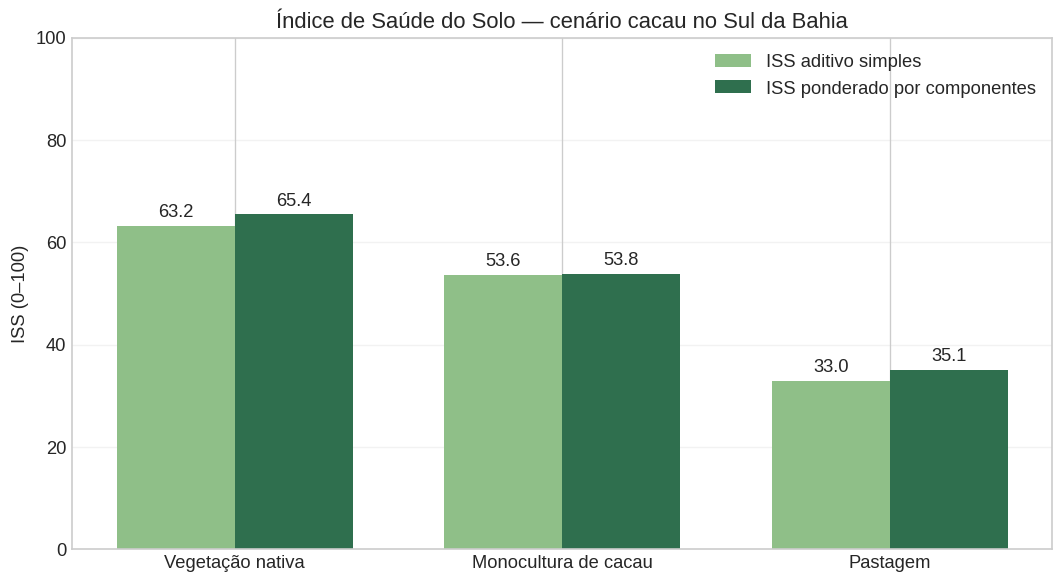

In [10]:
# -------------------------------------------------------------------------
# GRÁFICO 1 — ISS final por uso da terra
# -------------------------------------------------------------------------

ordem = ["Vegetação nativa", "Monocultura de cacau", "Pastagem"]
plot_df = medias.set_index("Uso da terra").loc[ordem].reset_index()

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(plot_df))
width = 0.36

ax.bar(
    x - width/2,
    plot_df["ISS_aditivo_simples_0_100"],
    width,
    label="ISS aditivo simples",
    color="#8fbf88"
)

ax.bar(
    x + width/2,
    plot_df["ISS_ponderado_componentes_0_100"],
    width,
    label="ISS ponderado por componentes",
    color="#2f6f4e"
)

ax.set_xticks(x)
ax.set_xticklabels(plot_df["Uso da terra"], rotation=0)
ax.set_ylabel("ISS (0–100)")
ax.set_title("Índice de Saúde do Solo — cenário cacau no Sul da Bahia")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.25)

# Escreve o valor em cima das barras.
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.savefig("grafico_ISS_cacau_Sul_Bahia_Colab.png", dpi=300, bbox_inches="tight")
plt.show()

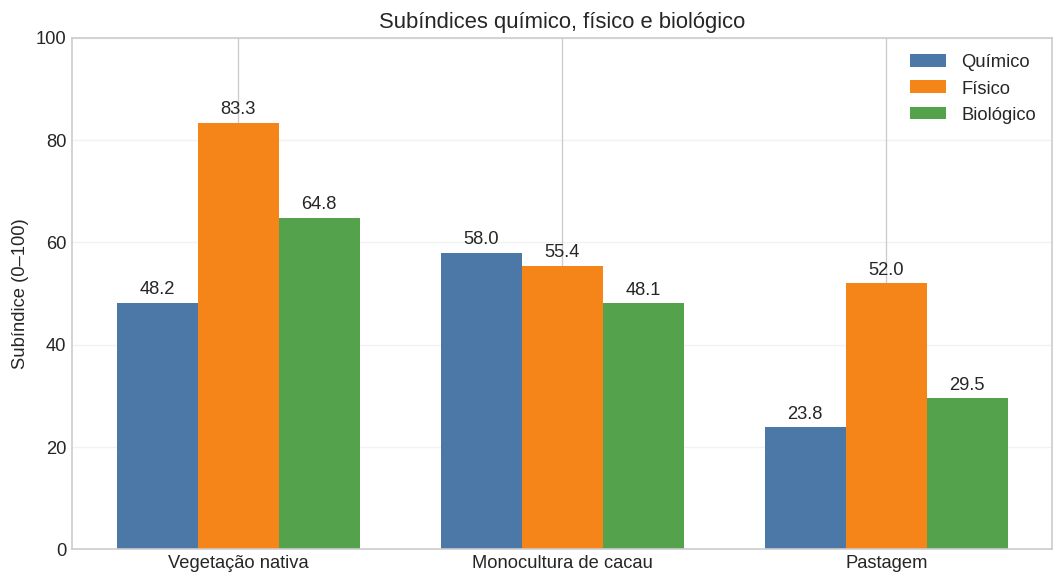

In [11]:
# -------------------------------------------------------------------------
# GRÁFICO 2 — Componentes químico, físico e biológico
# -------------------------------------------------------------------------

componentes_cols = ["ISS_Químico", "ISS_Físico", "ISS_Biológico"]
comp_plot = plot_df[["Uso da terra"] + componentes_cols].copy()

fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(comp_plot))
width = 0.25
cores = ["#4c78a8", "#f58518", "#54a24b"]

for i, col in enumerate(componentes_cols):
    ax.bar(x + (i - 1) * width, comp_plot[col] * 100, width, label=col.replace("ISS_", ""), color=cores[i])

ax.set_xticks(x)
ax.set_xticklabels(comp_plot["Uso da terra"])
ax.set_ylabel("Subíndice (0–100)")
ax.set_title("Subíndices químico, físico e biológico")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.25)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()
plt.savefig("grafico_componentes_cacau_Sul_Bahia_Colab.png", dpi=300, bbox_inches="tight")
plt.show()

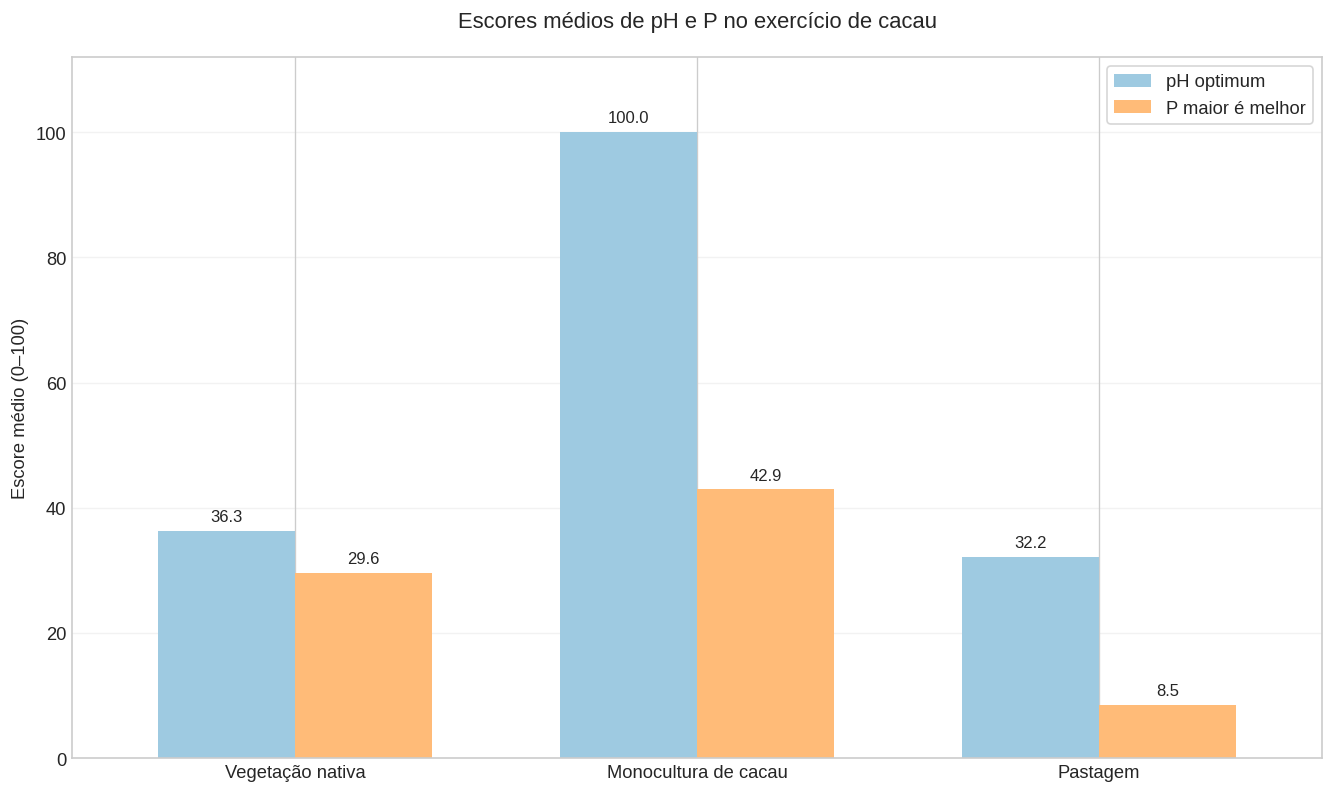

In [12]:
# -------------------------------------------------------------------------
# GRÁFICO 3 — Escores específicos de pH e P
# -------------------------------------------------------------------------

ph_p_cols = ["pH_score", "Fósforo_score"]
ph_p_medias = scores.groupby("Uso da terra")[ph_p_cols].mean().loc[ordem].reset_index()

x = np.arange(len(ph_p_medias))
width = 0.34

fig, ax = plt.subplots(figsize=(11, 6.5), constrained_layout=True)

barras_ph = ax.bar(x - width/2, ph_p_medias["pH_score"] * 100, width, label="pH optimum", color="#9ecae1")
barras_p = ax.bar(x + width/2, ph_p_medias["Fósforo_score"] * 100, width, label="P maior é melhor", color="#ffbb78")

ax.set_xticks(x)
ax.set_xticklabels(ph_p_medias["Uso da terra"], rotation=0, ha="center")
ax.set_ylabel("Escore médio (0–100)")
ax.set_title("Escores médios de pH e P no exercício de cacau", pad=18)
ax.set_ylim(0, 112)
ax.margins(x=0.08)
ax.legend(loc="upper right", frameon=True)
ax.grid(axis="y", alpha=0.25)

for barras in [barras_ph, barras_p]:
    ax.bar_label(barras, fmt="%.1f", padding=4, fontsize=10)

plt.savefig("grafico_scores_pH_P_cacau_Sul_Bahia_Colab.png", dpi=300, bbox_inches="tight")
plt.show()

## 9. Exportação da planilha final

A célula abaixo salva uma planilha Excel com quatro abas:

| Aba | Conteúdo |
|---|---|
| `Dados_e_scores` | dados originais, escores, subíndices e ISS por amostra |
| `Resumo_por_uso` | médias por uso da terra e Soil Health Gap |
| `Parametros_scoring` | regras usadas para cada indicador |
| `Referencias` | referências bibliográficas usadas no exercício |

In [13]:
# -------------------------------------------------------------------------
# EXPORTAÇÃO DA PLANILHA FINAL
# -------------------------------------------------------------------------

referencias = pd.DataFrame({
    "Referência": [
        "ANDREWS, S. S.; KARLEN, D. L.; CAMBARDELLA, C. A. The Soil Management Assessment Framework: a quantitative soil quality evaluation method. Soil Science Society of America Journal, 68: 1945–1962, 2004.",
        "CHEPOTE, R. E.; SANTANA, S. O.; ARAÚJO, Q. R.; et al. Recomendações de corretivos e fertilizantes na cultura do cacaueiro no Sul da Bahia. Ilhéus: CEPLAC, Boletim Técnico 203, 2013.",
        "SNOECK, D.; et al. Cacao nutrition and fertilization. 2016. Referência usada como suporte internacional para níveis críticos de P em cacau, com ressalva sobre método extrator.",
        "KONGOR, J. E.; et al. Soil fertility and nutrient management in cocoa systems in Ghana. 2019. Referência usada como suporte internacional para adequação de P, com ressalva sobre método extrator.",
        "DOE, E. K.; et al. Soil fertility status and cocoa productivity relationships in Ghanaian cocoa systems. 2022. Referência usada como suporte internacional para faixa ótima mais ampla de P, com ressalva sobre método extrator.",
        "MANRIQUE, L. A.; et al. Soil Quality Index in Cocoa Crops. TEM Journal, 13(1): 286–292, 2024. DOI: 10.18421/TEM131-30.",
        "CHERUBIN, M. R.; KARLEN, D. L.; FRANCO, A. L. C.; et al. Soil quality indexing strategies for evaluating sugarcane expansion in Brazil. PLOS ONE, 11(3): e0150860, 2016."
    ]
})

arquivo_excel = "ExercicioISS_2026_cacau_Sul_Bahia_Colab.xlsx"

with pd.ExcelWriter(arquivo_excel, engine="openpyxl") as writer:
    calculo_completo.to_excel(writer, sheet_name="Dados_e_scores", index=False)
    medias_apresentacao.to_excel(writer, sheet_name="Resumo_por_uso", index=False)
    parametros_df.to_excel(writer, sheet_name="Parametros_scoring", index=False)
    referencias.to_excel(writer, sheet_name="Referencias", index=False)

# Pequena formatação visual do Excel.
wb = load_workbook(arquivo_excel)
for ws in wb.worksheets:
    ws.freeze_panes = "A2"
    for cell in ws[1]:
        cell.font = Font(bold=True, color="FFFFFF")
        cell.fill = PatternFill("solid", fgColor="2F6F4E")
        cell.alignment = Alignment(horizontal="center", vertical="center", wrap_text=True)
    for col in ws.columns:
        max_len = max(len(str(cell.value)) if cell.value is not None else 0 for cell in col)
        ws.column_dimensions[get_column_letter(col[0].column)].width = min(max(max_len + 2, 12), 55)

wb.save(arquivo_excel)
print(f"Planilha salva: {arquivo_excel}")

Planilha salva: ExercicioISS_2026_cacau_Sul_Bahia_Colab.xlsx


## 10. Interpretação dos resultados

O resultado final esperado para o **ISS ponderado por componentes** é:

| Uso da terra | ISS ponderado por componentes | Soil Health Gap |
|---|---:|---:|
| Vegetação nativa | 65,56 | 0,00 |
| Monocultura de cacau | 54,51 | 11,05 |
| Pastagem | 34,62 | 30,94 |

O ranking final foi **vegetação nativa > monocultura de cacau > pastagem**. A vegetação nativa apresentou a melhor condição, como esperado para a referência menos perturbada. A monocultura de cacau apresentou condição intermediária, com desempenho superior ao da pastagem, mas ainda abaixo da vegetação nativa. A pastagem apresentou o maior Soil Health Gap, indicando maior distância em relação à referência.

A interpretação por componentes mostrou que a monocultura de cacau teve componente químico relativamente alto, associado principalmente ao pH dentro da faixa ótima adotada e ao maior P relativo dentro da faixa observada do exercício. Entretanto, os componentes físico e biológico ficaram abaixo da vegetação nativa. Isso sugere que, para reduzir o Soil Health Gap em áreas de cacau no Sul da Bahia, práticas como aumento de cobertura do solo, manutenção de serapilheira, diversificação vegetal, adubação orgânica, redução de revolvimento e proteção da estrutura do solo podem ser estratégias relevantes.

## 11. Limitações metodológicas

Este exercício é uma aplicação didática e não substitui uma calibração oficial do SMAF para cacau no Sul da Bahia. O pH foi tratado por curva **optimum**. O P disponível foi tratado como **maior é melhor apenas dentro da faixa observada**, porque os valores do exercício são relativamente baixos a moderados. A discussão sobre valor máximo de P deve ser apresentada somente como **salvaguarda expert-informed para extrapolação futura**, e não como limiar validado de toxicidade ou antagonismo nutricional em cacau [2].

Além disso, indicadores como potássio, densidade, macroagregação, BG, COS e CBM foram pontuados por normalização min–máx relativa ao próprio conjunto de dados.

## 12. Referências bibliográficas

[1] ANDREWS, S. S.; KARLEN, D. L.; CAMBARDELLA, C. A. **The Soil Management Assessment Framework: a quantitative soil quality evaluation method**. *Soil Science Society of America Journal*, v. 68, p. 1945–1962, 2004.

[2] CHEPOTE, R. E.; SANTANA, S. O.; ARAÚJO, Q. R.; et al. **Recomendações de corretivos e fertilizantes na cultura do cacaueiro no Sul da Bahia**. Ilhéus: CEPLAC, Boletim Técnico 203, 2013.

[3] SNOECK, D.; et al. **Cacao nutrition and fertilization**. 2016. Referência usada como suporte internacional para níveis críticos de P em cacau, com ressalva sobre método extrator.

[4] KONGOR, J. E.; BOECKX, P.; VERMEIR, P.; VAN DE WALLE, D.; BAERT, G.; AFOAKWA, E. O.; DEWETTINCK, K. **Assessment of soil fertility and quality for improved cocoa production in six cocoa growing regions in Ghana.** Agroforestry Systems, v. 93, p. 1455–1467, 2019.

[5] MANRIQUE, L. A.; et al. **Soil Quality Index in Cocoa Crops**. *TEM Journal*, v. 13, n. 1, p. 286–292, 2024. DOI: 10.18421/TEM131-30.

[6] CHERUBIN, M. R.; KARLEN, D. L.; FRANCO, A. L. C.; et al. **Soil quality indexing strategies for evaluating sugarcane expansion in Brazil**. *PLOS ONE*, v. 11, n. 3, e0150860, 2016.

## 13. Download dos arquivos gerados no Colab

Depois de executar todo o notebook, rode a célula abaixo se quiser baixar a planilha e os gráficos diretamente para seu computador.

In [ ]:
# Esta célula funciona no Google Colab.
# Se estiver rodando fora do Colab, ela apenas exibirá uma mensagem.
try:
    from google.colab import files
    arquivos_para_baixar = [
        "ExercicioISS_2026_cacau_Sul_Bahia_Colab.xlsx",
        "grafico_ISS_cacau_Sul_Bahia_Colab.png",
        "grafico_componentes_cacau_Sul_Bahia_Colab.png",
        "grafico_scores_pH_P_cacau_Sul_Bahia_Colab.png",
    ]
    for arquivo in arquivos_para_baixar:
        files.download(arquivo)
except Exception as e:
    print("Download automático disponível apenas no Google Colab.")
    print("Os arquivos foram salvos na pasta atual do ambiente de execução.")